# TASK 5: MULTIPLE LINEAR REGRESSION

---

## Objectives

Build and evaluate a multiple linear regression model to predict **Calories_Burned** based on lifestyle and fitness variables.

### Research Question
**Can we accurately predict Calories_Burned using selected predictor variables?**

### Methodology
1. Load selected features from Task 4 (numerical + categorical)
2. Encode categorical variables
3. Train-test split
4. Assumption testing
5. VIF multicollinearity check
6. Model building (OLS regression)
7. Model evaluation
8. Coefficient interpretation
9. Prediction demonstration

---

## Setup: Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn dcor warnings

# Data manipulation
import pandas as pd
import numpy as np
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import shapiro, normaltest

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Regression analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Configuration
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


## Visualization Configuration

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.0)

COLORS = ['#2C3E50', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (12, 8),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

print("Visualization configured")

Visualization configured


---

## Section 5.1: Data Loading and Feature Preparation

Load dataset and prepare feature matrix with encoded categorical variables.

In [6]:
# Load dataset
df = pd.read_csv('Life_style_data_clean.csv')

print("="*80)
print("DATA LOADING")
print("="*80)

# Create data summary table with improved formatting
data_summary = pd.DataFrame({
    'Property': [
        'Rows',
        'Columns',
        'Memory Usage (MB)',
        'Target Variable',
        'Target Range',
        'Target Mean',
        'Target Std Dev'
    ],
    'Value': [
        f"{df.shape[0]:,}",
        f"{df.shape[1]}",
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}",
        'Calories_Burned',
        f"[{df['Calories_Burned'].min():.2f}, {df['Calories_Burned'].max():.2f}]",
        f"{df['Calories_Burned'].mean():.2f}",
        f"{df['Calories_Burned'].std():.2f}"
    ]
})

# Display styled table
print()
display(data_summary.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Dataset Summary"))

# Define target
target_var = 'Calories_Burned'

DATA LOADING



,Property,Value
0,Rows,"20,000"
1,Columns,15
2,Memory Usage (MB),4.05
3,Target Variable,Calories_Burned
4,Target Range,"[323.11, 2890.82]"
5,Target Mean,1280.11
6,Target Std Dev,502.23


### Load Selected Features from Task 4

In [7]:
print("\n" + "="*80)
print("LOADING SELECTED FEATURES FROM TASK 4")
print("="*80)

# Try loading pickle file (recommended)
try:
    with open('all_selected_features.pkl', 'rb') as f:
        all_selected_features = pickle.load(f)

    print("\nLoaded from: all_selected_features.pkl")
    selected_features_numerical = all_selected_features['numerical']
    selected_features_categorical = all_selected_features['categorical']

except FileNotFoundError:
    print("\nall_selected_features.pkl not found")
    print("Trying CSV files...")

    try:
        # Load numerical
        numerical_df = pd.read_csv('selected_features_for_task5.csv')
        selected_features_numerical = numerical_df['Variable'].tolist()

        # Load categorical
        try:
            categorical_df = pd.read_csv('selected_categorical_features.csv')
            selected_features_categorical = categorical_df['Variable'].tolist()
        except FileNotFoundError:
            selected_features_categorical = []

        print("Loaded from CSV files")

    except FileNotFoundError:
        print("\n No feature files found!")
        print("Using default features from Task 1")

        selected_features_numerical = [
            'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
            'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
            'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Experience_Level'
        ]
        selected_features_categorical = []

print(f"\nNUMERICAL FEATURES: {len(selected_features_numerical)}")
for i, feat in enumerate(selected_features_numerical, 1):
    print(f"  {i}. {feat}")

print(f"\nCATEGORICAL FEATURES: {len(selected_features_categorical)}")
for i, feat in enumerate(selected_features_categorical, 1):
    print(f"  {i}. {feat}")


LOADING SELECTED FEATURES FROM TASK 4

Loaded from: all_selected_features.pkl

NUMERICAL FEATURES: 3
  1. Session_Duration (hours)
  2. Experience_Level
  3. Water_Intake (liters)

CATEGORICAL FEATURES: 1
  1. Workout_Type


### Encode Categorical Variables and Create Feature Matrix

In [8]:
print("\n" + "="*80)
print("FEATURE MATRIX PREPARATION")
print("="*80)

# Verify features exist
missing = []
for feat in selected_features_numerical + selected_features_categorical:
    if feat not in df.columns:
        missing.append(feat)

if missing:
    raise ValueError(f"Missing features: {missing}")

print("All features found in dataset")

# Extract numerical features
X_numerical = df[selected_features_numerical].copy()
print(f"\nNumerical features: {X_numerical.shape}")

# Encode categorical features
if len(selected_features_categorical) > 0:
    print(f"\nEncoding {len(selected_features_categorical)} categorical feature(s)...")

    X_categorical_list = []
    for cat_feat in selected_features_categorical:
        # One-hot encoding with drop_first=True
        encoded = pd.get_dummies(df[cat_feat], prefix=cat_feat, drop_first=True)
        print(f"  - {cat_feat}: {len(df[cat_feat].unique())} categories → {encoded.shape[1]} dummy variable(s)")
        X_categorical_list.append(encoded)

    X_categorical = pd.concat(X_categorical_list, axis=1)
    X = pd.concat([X_numerical, X_categorical], axis=1)
    print(f"\nCombined feature matrix: {X.shape}")
else:
    X = X_numerical.copy()
    print(f"\nNo categorical features, using numerical only: {X.shape}")

# Target variable
y = df[target_var].copy()

# Summary
print("\n" + "-"*80)
print("FEATURE SUMMARY")
print("-"*80)
print(f"  Numerical features: {len(selected_features_numerical)}")
print(f"  Categorical features: {len(selected_features_categorical)}")
print(f"  Total predictors: {X.shape[1]}")
print(f"  Target: {target_var}")
print(f"  Samples: {len(X)}")
print(f"  Missing values: {X.isnull().sum().sum()}")

print("\nFeature matrix ready")


FEATURE MATRIX PREPARATION
All features found in dataset

Numerical features: (20000, 3)

Encoding 1 categorical feature(s)...
  - Workout_Type: 4 categories → 3 dummy variable(s)

Combined feature matrix: (20000, 6)

--------------------------------------------------------------------------------
FEATURE SUMMARY
--------------------------------------------------------------------------------
  Numerical features: 3
  Categorical features: 1
  Total predictors: 6
  Target: Calories_Burned
  Samples: 20000
  Missing values: 0

Feature matrix ready


---

## Section 5.2: Train-Test Split

Split data into training (80%) and testing (20%) sets.

In [9]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Create summary table
split_summary = pd.DataFrame({
    'Set': ['Training', 'Testing', 'Total'],
    'Samples': [len(X_train), len(X_test), len(X)],
    'Percentage': [f"{100*(1-TEST_SIZE):.0f}%", f"{100*TEST_SIZE:.0f}%", "100%"],
    'Target Mean': [f"{y_train.mean():.2f}", f"{y_test.mean():.2f}", f"{y.mean():.2f}"],
    'Target Std': [f"{y_train.std():.2f}", f"{y_test.std():.2f}", f"{y.std():.2f}"]
})

print("\nTrain-test split complete\n")
display(split_summary.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Train-Test Split Summary"))

TRAIN-TEST SPLIT

Train-test split complete



,Set,Samples,Percentage,Target Mean,Target Std
0,Training,16000,80%,1280.54,502.94
1,Testing,4000,20%,1278.39,499.44
2,Total,20000,100%,1280.11,502.23


### Visualization: Train-Test Split Distribution

Compare the distribution of target variable between training and testing sets to ensure representative sampling.

TRAIN-TEST DISTRIBUTION COMPARISON


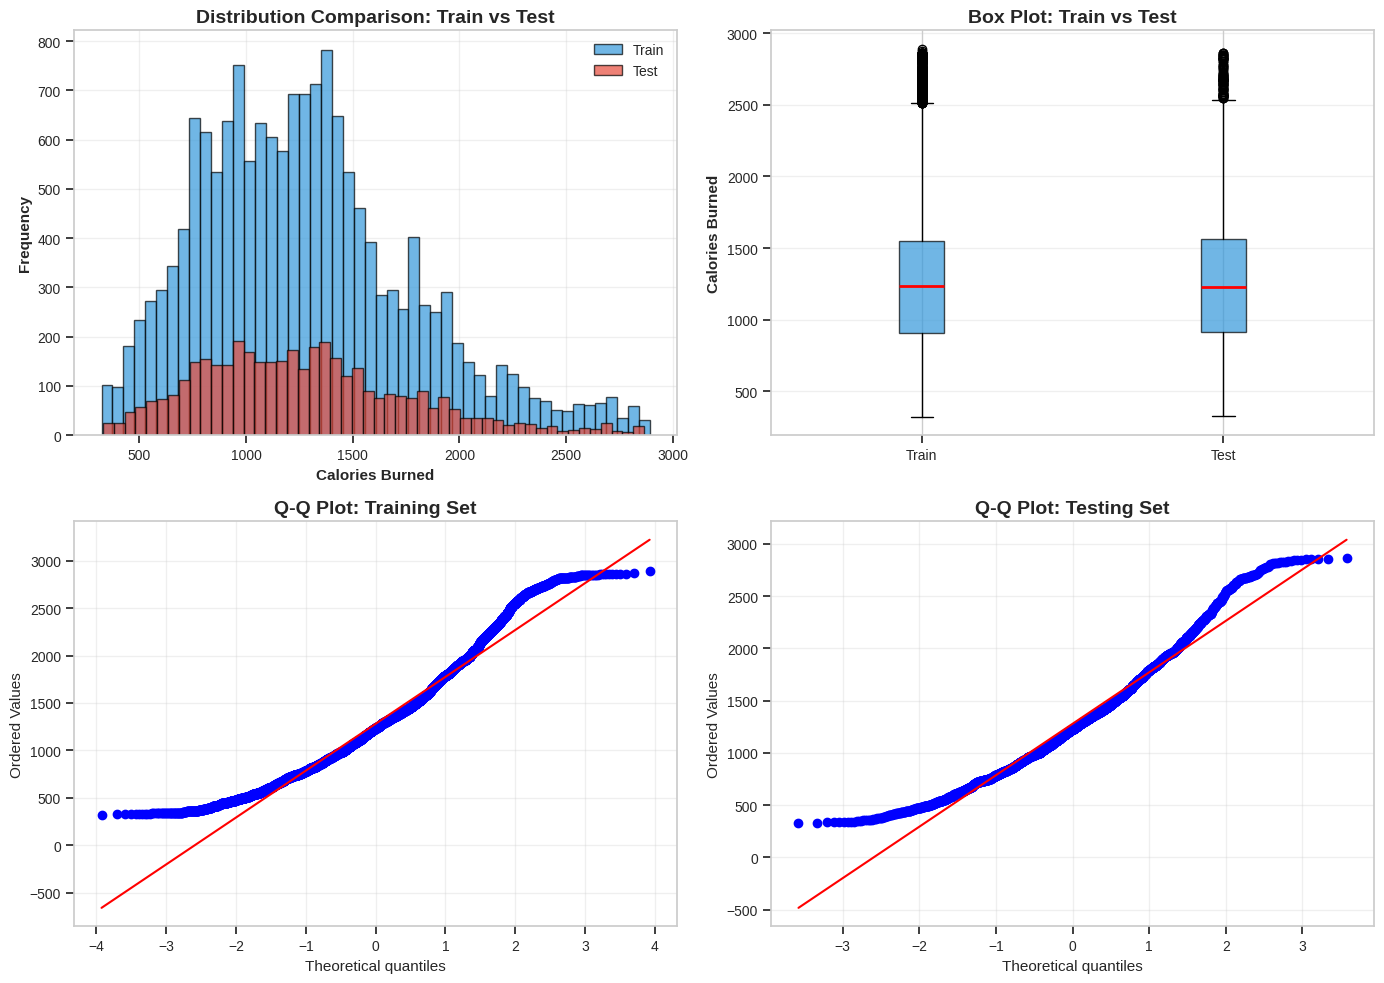


Interpretation:
  TOP-LEFT: Histograms show similar distributions between train and test sets
  TOP-RIGHT: Box plots confirm similar central tendency and spread
  BOTTOM: Q-Q plots assess normality of target variable in both sets

Conclusion:
  GOOD: Train and test sets are well-balanced and representative


In [10]:
print("="*80)
print("TRAIN-TEST DISTRIBUTION COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram comparison
axes[0, 0].hist(y_train, bins=50, alpha=0.7, label='Train', color='#3498DB', edgecolor='black')
axes[0, 0].hist(y_test, bins=50, alpha=0.7, label='Test', color='#E74C3C', edgecolor='black')
axes[0, 0].set_xlabel('Calories Burned', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Distribution Comparison: Train vs Test', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot comparison
data_split = pd.DataFrame({
    'Calories': np.concatenate([y_train, y_test]),
    'Set': ['Train']*len(y_train) + ['Test']*len(y_test)
})
axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'], patch_artist=True,
                    boxprops=dict(facecolor='#3498DB', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Calories Burned', fontweight='bold')
axes[0, 1].set_title('Box Plot: Train vs Test', fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Q-Q plot for train
stats.probplot(y_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Training Set', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot for test
stats.probplot(y_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Testing Set', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('T_T.png', dpi=450, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  TOP-LEFT: Histograms show similar distributions between train and test sets")
print("  TOP-RIGHT: Box plots confirm similar central tendency and spread")
print("  BOTTOM: Q-Q plots assess normality of target variable in both sets")
print("\nConclusion:")
if abs(y_train.mean() - y_test.mean()) < 10:
    print("  GOOD: Train and test sets are well-balanced and representative")
else:
    print("  WARNING: Slight difference detected between train and test distributions")

---

## Section 5.3: Multicollinearity Check (VIF)

Calculate Variance Inflation Factor for all predictors.

VARIANCE INFLATION FACTOR (VIF) ANALYSIS



,Feature,VIF,Status
1,Experience_Level,2.39,Good
0,Session_Duration (hours),2.35,Good
4,Workout_Type_Strength,1.51,Good
5,Workout_Type_Yoga,1.51,Good
3,Workout_Type_HIIT,1.50,Good
2,Water_Intake (liters),1.12,Good


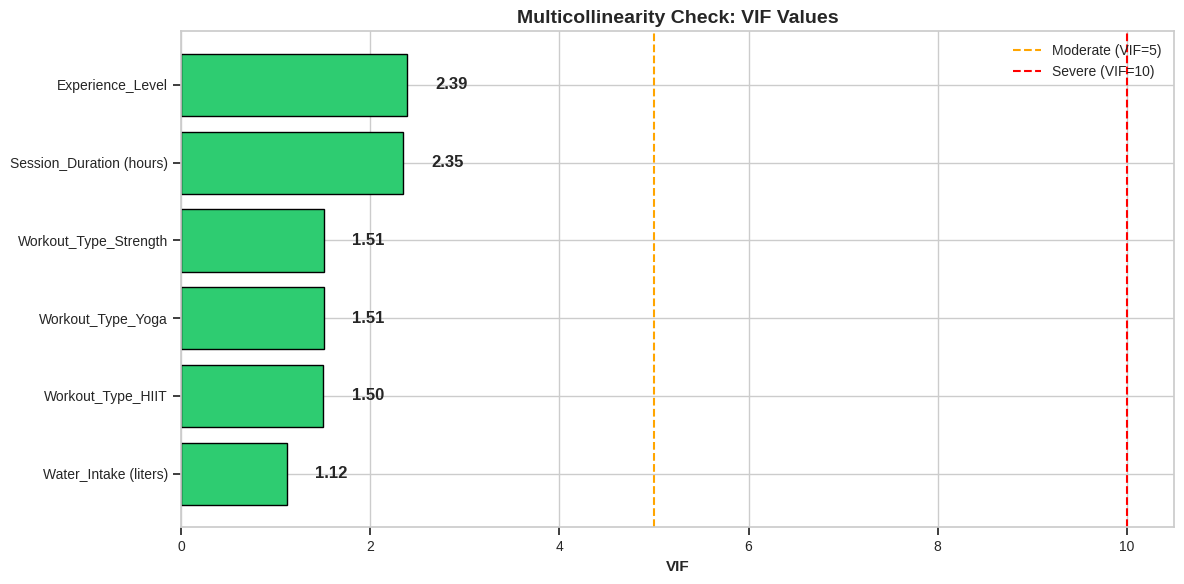


VIF Summary:


,Category,Count,Percentage
0,Severe (VIF >= 10),0,0.0%
1,Moderate (5 <= VIF < 10),0,0.0%
2,Good (VIF < 5),6,100.0%
3,Total Features,6,100.0%


In [11]:
print("="*80)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*80)

# Convert to float64 (dummy variables from pd.get_dummies are uint8)
X_train_float = X_train.astype('float64')
X_train_const = sm.add_constant(X_train_float)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i+1)
                   for i in range(len(X_train.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data['Status'] = vif_data['VIF'].apply(
    lambda x: 'Severe' if x >= 10 else 'Moderate' if x >= 5 else 'Good'
)

print()
display(vif_data.style
    .background_gradient(subset=['VIF'], cmap='RdYlGn_r', vmin=0, vmax=15)
    .format({'VIF': '{:.2f}'})
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Variance Inflation Factor (VIF) Analysis"))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if x >= 10 else '#f39c12' if x >= 5 else '#2ecc71' for x in vif_data['VIF']]
bars = ax.barh(range(len(vif_data)), vif_data['VIF'], color=colors, edgecolor='black')
ax.set_yticks(range(len(vif_data)))
ax.set_yticklabels(vif_data['Feature'])
ax.set_xlabel('VIF', fontweight='bold')
ax.set_title('Multicollinearity Check: VIF Values', fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', label='Moderate (VIF=5)')
ax.axvline(10, color='red', linestyle='--', label='Severe (VIF=10)')
ax.legend()
ax.invert_yaxis()
for i, v in enumerate(vif_data['VIF']):
    ax.text(v + 0.3, i, f'{v:.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('Mul.png', dpi=450, bbox_inches='tight')
plt.show()

# Summary
n_severe = (vif_data['VIF'] >= 10).sum()
n_moderate = ((vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)).sum()
n_good = (vif_data['VIF'] < 5).sum()

vif_summary_table = pd.DataFrame({
    'Category': ['Severe (VIF >= 10)', 'Moderate (5 <= VIF < 10)', 'Good (VIF < 5)', 'Total Features'],
    'Count': [n_severe, n_moderate, n_good, len(vif_data)],
    'Percentage': [
        f"{100*n_severe/len(vif_data):.1f}%",
        f"{100*n_moderate/len(vif_data):.1f}%",
        f"{100*n_good/len(vif_data):.1f}%",
        "100.0%"
    ]
})

print("\nVIF Summary:")
display(vif_summary_table.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("VIF Category Summary"))

---

## Section 5.4: Build Regression Model

Fit multiple linear regression using OLS.

In [12]:
print("="*80)
print("BUILDING REGRESSION MODEL")
print("="*80)

# Sklearn model
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

# Statsmodels for detailed statistics
X_train_const = sm.add_constant(X_train.astype('float64'))
results_sm = sm.OLS(y_train, X_train_const).fit()

print("\nModel fitted successfully")

# Create model summary table
model_info = pd.DataFrame({
    'Metric': [
        'Model Type',
        'Number of Observations',
        'Number of Predictors',
        'R-squared',
        'Adjusted R-squared',
        'F-statistic',
        'Prob (F-statistic)',
        'AIC',
        'BIC'
    ],
    'Value': [
        'Ordinary Least Squares (OLS)',
        f"{int(results_sm.nobs)}",
        f"{results_sm.df_model}",
        f"{results_sm.rsquared:.4f}",
        f"{results_sm.rsquared_adj:.4f}",
        f"{results_sm.fvalue:.2f}",
        f"{results_sm.f_pvalue:.2e}",
        f"{results_sm.aic:.2f}",
        f"{results_sm.bic:.2f}"
    ]
})

print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)

display(model_info.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Regression Model Summary")
    .hide(axis='index'))

# Create coefficients table
coef_table = pd.DataFrame({
    'Feature': results_sm.params.index,
    'Coefficient': results_sm.params.values,
    'Std Error': results_sm.bse.values,
    't-value': results_sm.tvalues.values,
    'P-value': results_sm.pvalues.values,
    'CI [2.5%]': results_sm.conf_int()[0].values,
    'CI [97.5%]': results_sm.conf_int()[1].values
})

# Format numeric columns
coef_table['Coefficient'] = coef_table['Coefficient'].apply(lambda x: f"{x:.4f}")
coef_table['Std Error'] = coef_table['Std Error'].apply(lambda x: f"{x:.3f}")
coef_table['t-value'] = coef_table['t-value'].apply(lambda x: f"{x:.3f}")
coef_table['P-value'] = coef_table['P-value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
coef_table['CI [2.5%]'] = coef_table['CI [2.5%]'].apply(lambda x: f"{x:.3f}")
coef_table['CI [97.5%]'] = coef_table['CI [97.5%]'].apply(lambda x: f"{x:.3f}")

print("\n" + "="*80)
print("MODEL COEFFICIENTS")
print("="*80)

display(coef_table.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Regression Coefficients with 95% Confidence Intervals")
    .hide(axis='index'))

# Create diagnostic statistics table
try:
    from scipy import stats
    residuals_train = y_train - model_sk.predict(X_train)
    omni_stat, omni_pval = stats.jarque_bera(residuals_train)
    skew_val = stats.skew(residuals_train)
    kurt_val = stats.kurtosis(residuals_train)

    # Calculate Durbin-Watson
    from statsmodels.stats.stattools import durbin_watson
    dw_stat = durbin_watson(residuals_train)

    diag_stats = pd.DataFrame({
        'Test': [
            'Jarque-Bera (JB)',
            'Prob(JB)',
            'Skewness',
            'Kurtosis',
            'Durbin-Watson',
            'Condition Number'
        ],
        'Value': [
            f"{omni_stat:.3f}",
            f"{omni_pval:.3e}",
            f"{skew_val:.3f}",
            f"{kurt_val:.3f}",
            f"{dw_stat:.3f}",
            f"{results_sm.condition_number:.1f}"
        ],
        'Interpretation': [
            'Test for normality',
            'p-value for JB test',
            'Measure of asymmetry',
            'Measure of tail heaviness',
            'Test for autocorrelation',
            'Multicollinearity indicator'
        ]
    })
except Exception as e:
    diag_stats = pd.DataFrame({
        'Test': ['Note'],
        'Value': ['Diagnostics available in detailed output below'],
        'Interpretation': ['See statsmodels summary']
    })

print("\n" + "="*80)
print("DIAGNOSTIC STATISTICS")
print("="*80)

display(diag_stats.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Model Diagnostic Tests")
    .hide(axis='index'))

print("\nModel building and evaluation complete")

BUILDING REGRESSION MODEL

Model fitted successfully

MODEL SUMMARY


Metric,Value
Model Type,Ordinary Least Squares (OLS)
Number of Observations,16000
Number of Predictors,6.0
R-squared,0.9680
Adjusted R-squared,0.9680
F-statistic,80661.62
Prob (F-statistic),0.00e+00
AIC,189395.80
BIC,189449.57



MODEL COEFFICIENTS


Feature,Coefficient,Std Error,t-value,P-value,CI [2.5%],CI [97.5%]
const,-291.6288,3.940,-74.020,0.00e+00,-299.351,-283.906
Session_Duration (hours),992.1239,3.198,310.214,0.00e+00,985.855,998.393
Experience_Level,120.7890,1.489,81.098,0.00e+00,117.870,123.708
Water_Intake (liters),10.6930,1.240,8.625,7.02e-18,8.263,13.123
Workout_Type_HIIT,452.9446,2.021,224.100,0.00e+00,448.983,456.906
Workout_Type_Strength,151.1700,2.007,75.337,0.00e+00,147.237,155.103
Workout_Type_Yoga,-296.3895,2.014,-147.150,0.00e+00,-300.338,-292.441



DIAGNOSTIC STATISTICS


Test,Value,Interpretation
Jarque-Bera (JB),4298.084,Test for normality
Prob(JB),0.000e+00,p-value for JB test
Skewness,0.733,Measure of asymmetry
Kurtosis,2.074,Measure of tail heaviness
Durbin-Watson,1.989,Test for autocorrelation
Condition Number,23.5,Multicollinearity indicator



Model building and evaluation complete


---

## Section 5.5: Model Evaluation

Evaluate model performance on training and test sets.

MODEL PERFORMANCE



,Metric,Set,Value,Unit
0,R-squared,Training,0.9680,proportion
1,R-squared,Testing,0.9668,proportion
2,RMSE,Testing,90.93,calories
3,MAE,Testing,60.61,calories


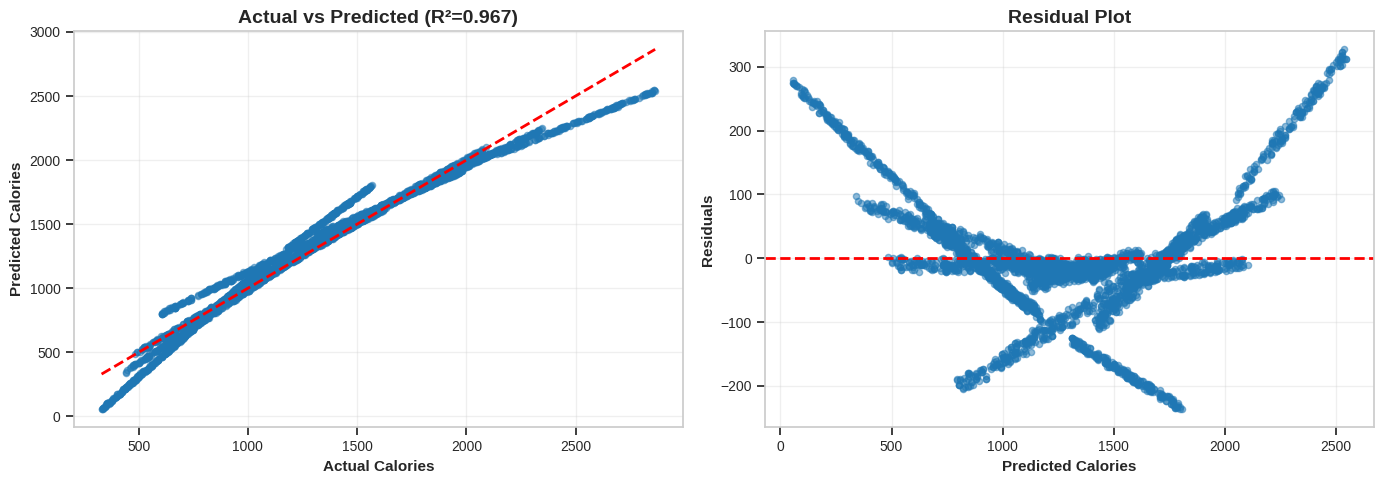


Model evaluation complete


In [13]:
# Predictions
y_train_pred = model_sk.predict(X_train)
y_test_pred = model_sk.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("="*80)
print("MODEL PERFORMANCE")
print("="*80)

# Create performance table
performance_metrics = pd.DataFrame({
    'Metric': ['R-squared', 'R-squared', 'RMSE', 'MAE'],
    'Set': ['Training', 'Testing', 'Testing', 'Testing'],
    'Value': [f"{train_r2:.4f}", f"{test_r2:.4f}", f"{test_rmse:.2f}", f"{test_mae:.2f}"],
    'Unit': ['proportion', 'proportion', 'calories', 'calories']
})

print()
display(performance_metrics.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Model Performance Metrics"))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Calories', fontweight='bold')
axes[0].set_ylabel('Predicted Calories', fontweight='bold')
axes[0].set_title(f'Actual vs Predicted (R²={test_r2:.3f})', fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Calories', fontweight='bold')
axes[1].set_ylabel('Residuals', fontweight='bold')
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Pred.png', dpi=450, bbox_inches='tight')
plt.show()

print("\nModel evaluation complete")

### Additional Visualization: Comprehensive Model Diagnostics

Perform detailed diagnostic checks for regression assumptions.

REGRESSION DIAGNOSTICS - FOUR PLOT ANALYSIS


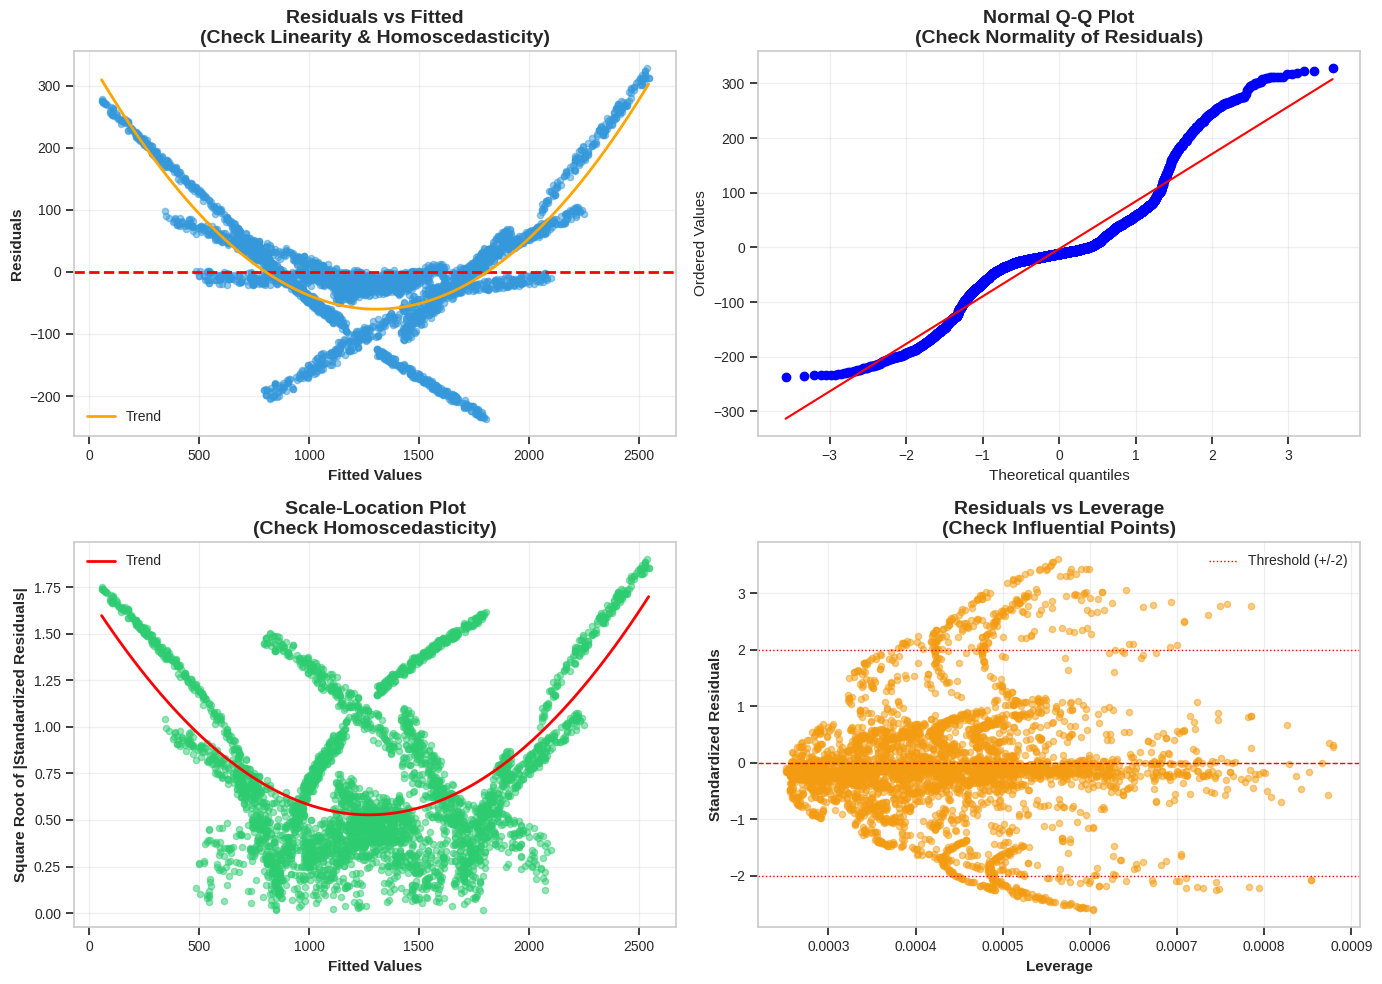


Diagnostic Interpretation:
--------------------------------------------------------------------------------



,Test,Metric,Value,Threshold,Status
0,Linearity,Residual Mean,-2.8355,< 1.0,CHECK
1,Normality,Shapiro-Wilk p-value,0.0000,> 0.05,CHECK
2,Homoscedasticity,Spread Range,1.8800,< 3.0,PASS
3,Outliers,Count (|std res| > 2),368 (9.2%),< 5%,CHECK



OVERALL DIAGNOSTIC ASSESSMENT



,Category,Value
0,Checks Passed,1
1,Checks Failed,3
2,Success Rate,25%



Conclusion:
  Model violates multiple assumptions, consider transformation


In [22]:
print("="*80)
print("REGRESSION DIAGNOSTICS - FOUR PLOT ANALYSIS")
print("="*80)

residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred
standardized_residuals = residuals_test / np.std(residuals_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_test_pred, residuals_test, alpha=0.5, s=20, color='#3498DB')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted\n(Check Linearity & Homoscedasticity)', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(y_test_pred, residuals_test, 2)
p = np.poly1d(z)
x_trend = np.linspace(y_test_pred.min(), y_test_pred.max(), 100)
axes[0, 0].plot(x_trend, p(x_trend), color='orange', linewidth=2, label='Trend')
axes[0, 0].legend()

# 2. Normal Q-Q Plot of Residuals
stats.probplot(residuals_test, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot\n(Check Normality of Residuals)', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Scale-Location (Spread-Location)
sqrt_standardized_residuals = np.sqrt(np.abs(standardized_residuals))
axes[1, 0].scatter(y_test_pred, sqrt_standardized_residuals, alpha=0.5, s=20, color='#2ECC71')
axes[1, 0].set_xlabel('Fitted Values', fontweight='bold')
axes[1, 0].set_ylabel('Square Root of |Standardized Residuals|', fontweight='bold')
axes[1, 0].set_title('Scale-Location Plot\n(Check Homoscedasticity)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Add trend line
z2 = np.polyfit(y_test_pred, sqrt_standardized_residuals, 2)
p2 = np.poly1d(z2)
axes[1, 0].plot(x_trend, p2(x_trend), color='red', linewidth=2, label='Trend')
axes[1, 0].legend()

# 4. Residuals vs Leverage (Cook's Distance)
X_test_const = sm.add_constant(X_test.astype('float64'))
influence = results_sm.get_influence()
leverage = influence.hat_matrix_diag[:len(y_train)]
cooks_d = influence.cooks_distance[0][:len(y_train)]

# For test set, calculate leverage manually
# Convert DataFrames to numpy arrays for matrix multiplication
X_test_const_array = X_test_const.values
X_train_const_array = X_train_const.values

H_test = X_test_const_array @ np.linalg.inv(X_train_const_array.T @ X_train_const_array) @ X_test_const_array.T
leverage_test = np.diag(H_test)

axes[1, 1].scatter(leverage_test, standardized_residuals, alpha=0.5, s=20, color='#F39C12')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 1].axhline(2, color='red', linestyle=':', linewidth=1, label='Threshold (+/-2)')
axes[1, 1].axhline(-2, color='red', linestyle=':', linewidth=1)
axes[1, 1].set_xlabel('Leverage', fontweight='bold')
axes[1, 1].set_ylabel('Standardized Residuals', fontweight='bold')
axes[1, 1].set_title('Residuals vs Leverage\n(Check Influential Points)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('REGRESSION_DIAGNOSTICS.png', dpi=450, bbox_inches='tight')
plt.show()

print("\nDiagnostic Interpretation:")
print("-"*80)

# Calculate all diagnostic metrics
residual_mean = np.mean(residuals_test)

# Shapiro-Wilk test for normality
if len(residuals_test) <= 5000:
    stat_sw, p_sw = shapiro(residuals_test)
else:
    stat_sw, p_sw = shapiro(residuals_test.sample(5000, random_state=42))

spread_range = sqrt_standardized_residuals.max() - sqrt_standardized_residuals.min()
n_outliers = np.sum(np.abs(standardized_residuals) > 2)
outlier_pct = 100 * n_outliers / len(standardized_residuals)

# Create diagnostic summary table
diagnostic_results = pd.DataFrame({
    'Test': [
        'Linearity',
        'Normality',
        'Homoscedasticity',
        'Outliers'
    ],
    'Metric': [
        'Residual Mean',
        'Shapiro-Wilk p-value',
        'Spread Range',
        'Count (|std res| > 2)'
    ],
    'Value': [
        f"{residual_mean:.4f}",
        f"{p_sw:.4f}",
        f"{spread_range:.4f}",
        f"{n_outliers} ({outlier_pct:.1f}%)"
    ],
    'Threshold': [
        '< 1.0',
        '> 0.05',
        '< 3.0',
        '< 5%'
    ],
    'Status': [
        'PASS' if abs(residual_mean) < 1 else 'CHECK',
        'PASS' if p_sw > 0.05 else 'CHECK',
        'PASS' if spread_range < 3 else 'CHECK',
        'PASS' if outlier_pct < 5 else 'CHECK'
    ]
})

print()
display(diagnostic_results.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .apply(lambda x: ['background-color: #2ECC71' if v == 'PASS' else 'background-color: #F39C12'
                      for v in x], subset=['Status'])
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Regression Diagnostic Tests"))

print("\n" + "="*80)
print("OVERALL DIAGNOSTIC ASSESSMENT")
print("="*80)
checks_passed = 0
if abs(residual_mean) < 1: checks_passed += 1
if p_sw > 0.05: checks_passed += 1
if spread_range < 3: checks_passed += 1
if outlier_pct < 5: checks_passed += 1

assessment_df = pd.DataFrame({
    'Category': ['Checks Passed', 'Checks Failed', 'Success Rate'],
    'Value': [f"{checks_passed}", f"{4 - checks_passed}", f"{checks_passed*25:.0f}%"]
})

print()
display(assessment_df.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Diagnostic Assessment Summary"))

print("\nConclusion:")
if checks_passed >= 3:
    print("  Model meets regression assumptions reasonably well")
elif checks_passed >= 2:
    print("  Model meets some assumptions, use with caution")
else:
    print("  Model violates multiple assumptions, consider transformation")

---

## Section 5.6: Coefficient Interpretation

Understand the effect of each predictor on Calories_Burned.

In [15]:
print("="*80)
print("COEFFICIENT INTERPRETATION")
print("="*80)

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + list(X_train.columns),
    'Coefficient': results_sm.params.values,
    'p-value': results_sm.pvalues.values
})

coef_df_sorted = pd.concat([
    coef_df[coef_df['Feature'] == 'Intercept'],
    coef_df[coef_df['Feature'] != 'Intercept'].sort_values('Coefficient', key=abs, ascending=False)
])

# Add significance indicator
coef_df_sorted['Significance'] = coef_df_sorted['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)

# Create styled display table
coef_display = coef_df_sorted.copy()
coef_display['Coefficient'] = coef_display['Coefficient'].apply(lambda x: f"{x:+.4f}")
coef_display['p-value'] = coef_display['p-value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")

print("\n")
display(coef_display.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("All Model Coefficients (Sorted by Absolute Magnitude)")
    .hide(axis='index'))

print("\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05")

# Separate numerical and categorical
print("\n" + "="*80)
print("DETAILED INTERPRETATION")
print("="*80)

print("\nA. NUMERICAL FEATURES:")
print("-"*80)

# Create numerical features interpretation table
num_interp = []
for feat in selected_features_numerical:
    if feat in coef_df_sorted['Feature'].values:
        row = coef_df_sorted[coef_df_sorted['Feature'] == feat].iloc[0]
        sig = '***' if row['p-value'] < 0.001 else '**' if row['p-value'] < 0.01 else '*' if row['p-value'] < 0.05 else ''
        direction = "increases" if row['Coefficient'] > 0 else "decreases"
        interpretation = f"1-unit increase → Calories {direction} by {abs(row['Coefficient']):.2f}" if row['p-value'] < 0.05 else "Not significant"

        num_interp.append({
            'Feature': feat,
            'Coefficient': f"{row['Coefficient']:+.4f}",
            'p-value': f"{row['p-value']:.2e}" if row['p-value'] < 0.001 else f"{row['p-value']:.4f}",
            'Sig.': sig,
            'Interpretation': interpretation
        })

if num_interp:
    num_df = pd.DataFrame(num_interp)
    print()
    display(num_df.style\
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black',
            'padding': '8px'
        })\
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#2C3E50'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid black'),
                ('padding', '10px')
            ]}
        ])\
        .set_caption("Numerical Features Interpretation")
        .hide(axis='index'))

if len(selected_features_categorical) > 0:
    print("\n\nB. CATEGORICAL FEATURES (Dummy Variables):")
    print("-"*80)
    print("Note: Coefficients show difference from baseline (dropped category)")

    cat_interp = []
    for cat_feat in selected_features_categorical:
        dummy_cols = [col for col in X_train.columns if col.startswith(cat_feat + '_')]

        if len(dummy_cols) > 0:
            # Determine baseline
            all_categories = df[cat_feat].unique()
            encoded_categories = [col.replace(cat_feat + '_', '') for col in dummy_cols]
            baseline = [cat for cat in all_categories if cat not in encoded_categories][0]

            # Add baseline row
            cat_interp.append({
                'Original Feature': cat_feat,
                'Category': f"{baseline} (baseline)",
                'Coefficient': '0.0000',
                'p-value': '-',
                'Sig.': '-',
                'Interpretation': 'Reference category'
            })

            for dummy_col in sorted(dummy_cols):
                if dummy_col in coef_df_sorted['Feature'].values:
                    row = coef_df_sorted[coef_df_sorted['Feature'] == dummy_col].iloc[0]
                    category = dummy_col.replace(cat_feat + '_', '')
                    sig = '***' if row['p-value'] < 0.001 else '**' if row['p-value'] < 0.01 else '*' if row['p-value'] < 0.05 else ''
                    direction = "higher" if row['Coefficient'] > 0 else "lower"
                    interpretation = f"{abs(row['Coefficient']):.2f} cal {direction} than {baseline}" if row['p-value'] < 0.05 else "Not significant"

                    cat_interp.append({
                        'Original Feature': cat_feat,
                        'Category': category,
                        'Coefficient': f"{row['Coefficient']:+.4f}",
                        'p-value': f"{row['p-value']:.2e}" if row['p-value'] < 0.001 else f"{row['p-value']:.4f}",
                        'Sig.': sig,
                        'Interpretation': interpretation
                    })

    if cat_interp:
        cat_df = pd.DataFrame(cat_interp)
        print()
        display(cat_df.style\
            .set_properties(**{
                'text-align': 'center',
                'border': '1px solid black',
                'padding': '8px'
            })\
            .set_table_styles([
                {'selector': 'th', 'props': [
                    ('background-color', '#2C3E50'),
                    ('color', 'white'),
                    ('font-weight', 'bold'),
                    ('text-align', 'center'),
                    ('border', '1px solid black'),
                    ('padding', '10px')
                ]}
            ])\
            .set_caption("Categorical Features Interpretation")
            .hide(axis='index'))

print("\nCoefficient interpretation complete")

COEFFICIENT INTERPRETATION




Feature,Coefficient,p-value,Significance
Intercept,-291.6288,0.00e+00,***
Session_Duration (hours),+992.1239,0.00e+00,***
Workout_Type_HIIT,+452.9446,0.00e+00,***
Workout_Type_Yoga,-296.3895,0.00e+00,***
Workout_Type_Strength,+151.1700,0.00e+00,***
Experience_Level,+120.7890,0.00e+00,***
Water_Intake (liters),+10.6930,7.02e-18,***



Significance codes: *** p<0.001, ** p<0.01, * p<0.05

DETAILED INTERPRETATION

A. NUMERICAL FEATURES:
--------------------------------------------------------------------------------



Feature,Coefficient,p-value,Sig.,Interpretation
Session_Duration (hours),+992.1239,0.00e+00,***,1-unit increase → Calories increases by 992.12
Experience_Level,+120.7890,0.00e+00,***,1-unit increase → Calories increases by 120.79
Water_Intake (liters),+10.6930,7.02e-18,***,1-unit increase → Calories increases by 10.69




B. CATEGORICAL FEATURES (Dummy Variables):
--------------------------------------------------------------------------------
Note: Coefficients show difference from baseline (dropped category)



Original Feature,Category,Coefficient,p-value,Sig.,Interpretation
Workout_Type,Cardio (baseline),0.0000,-,-,Reference category
Workout_Type,HIIT,+452.9446,0.00e+00,***,452.94 cal higher than Cardio
Workout_Type,Strength,+151.1700,0.00e+00,***,151.17 cal higher than Cardio
Workout_Type,Yoga,-296.3895,0.00e+00,***,296.39 cal lower than Cardio



Coefficient interpretation complete


### Visualization: Feature Importance Analysis

Visualize and compare the importance of different features based on coefficients and statistical significance.

FEATURE IMPORTANCE VISUALIZATION


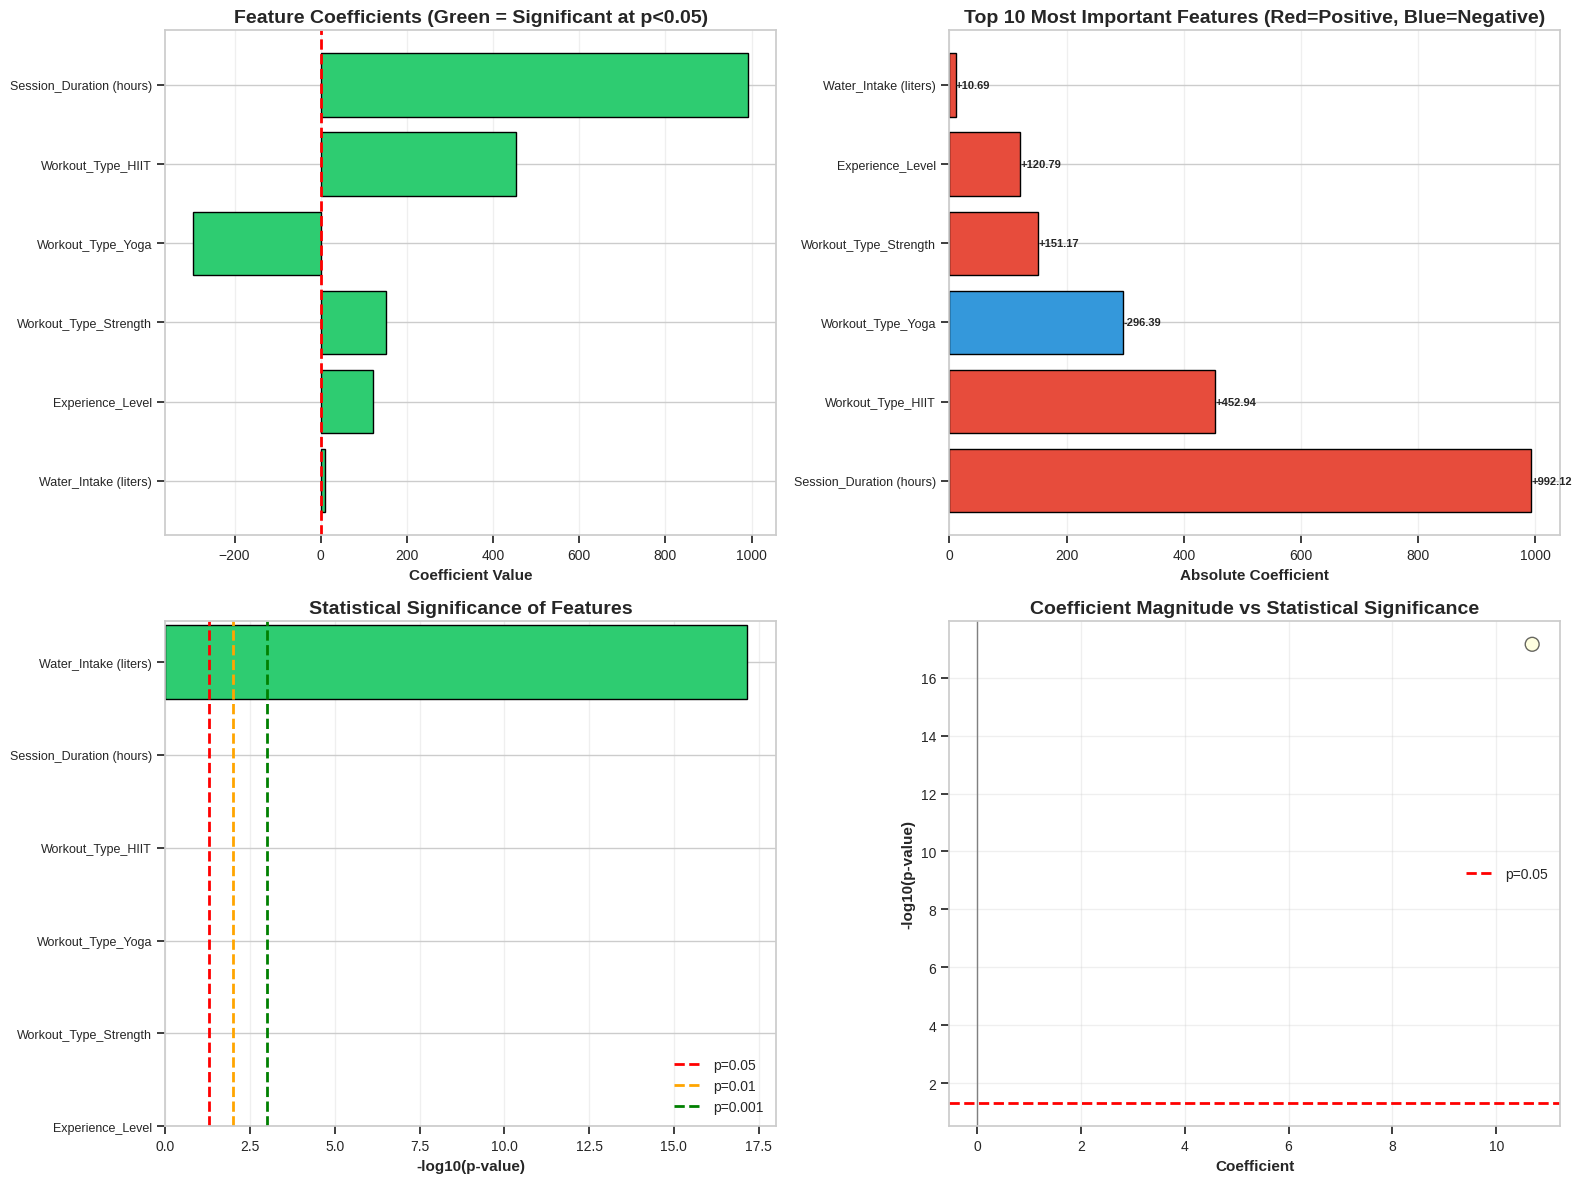

In [23]:
print("="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

# Prepare coefficient data (exclude intercept)
coef_viz = coef_df_sorted[coef_df_sorted['Feature'] != 'Intercept'].copy()
coef_viz['Abs_Coefficient'] = coef_viz['Coefficient'].abs()
coef_viz['Significant'] = coef_viz['p-value'] < 0.05
coef_viz = coef_viz.sort_values('Abs_Coefficient', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Coefficient Bar Chart (Horizontal)
colors_coef = ['#2ECC71' if sig else '#BDC3C7' for sig in coef_viz['Significant']]
axes[0, 0].barh(range(len(coef_viz)), coef_viz['Coefficient'], color=colors_coef, edgecolor='black')
axes[0, 0].set_yticks(range(len(coef_viz)))
axes[0, 0].set_yticklabels(coef_viz['Feature'], fontsize=9)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Coefficient Value', fontweight='bold')
axes[0, 0].set_title('Feature Coefficients (Green = Significant at p<0.05)', fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# 2. Absolute Coefficient Importance
top_n = 10
top_features = coef_viz.nlargest(top_n, 'Abs_Coefficient')
colors_abs = ['#E74C3C' if coef > 0 else '#3498DB' for coef in top_features['Coefficient']]
axes[0, 1].barh(range(len(top_features)), top_features['Abs_Coefficient'], color=colors_abs, edgecolor='black')
axes[0, 1].set_yticks(range(len(top_features)))
axes[0, 1].set_yticklabels(top_features['Feature'], fontsize=9)
axes[0, 1].set_xlabel('Absolute Coefficient', fontweight='bold')
axes[0, 1].set_title(f'Top {top_n} Most Important Features (Red=Positive, Blue=Negative)', fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')
for i, (idx, row) in enumerate(top_features.iterrows()):
    axes[0, 1].text(row['Abs_Coefficient'] + 0.5, i, f"{row['Coefficient']:+.2f}",
                    va='center', fontweight='bold', fontsize=8)

# 3. Statistical Significance Visualization
coef_viz_sorted_p = coef_viz.sort_values('p-value', ascending=True).head(15)
colors_p = ['#2ECC71' if p < 0.001 else '#F39C12' if p < 0.01 else '#3498DB' if p < 0.05 else '#E74C3C'
            for p in coef_viz_sorted_p['p-value']]
axes[1, 0].barh(range(len(coef_viz_sorted_p)), -np.log10(coef_viz_sorted_p['p-value']),
                color=colors_p, edgecolor='black')
axes[1, 0].set_yticks(range(len(coef_viz_sorted_p)))
axes[1, 0].set_yticklabels(coef_viz_sorted_p['Feature'], fontsize=9)
axes[1, 0].axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
axes[1, 0].axvline(-np.log10(0.01), color='orange', linestyle='--', linewidth=2, label='p=0.01')
axes[1, 0].axvline(-np.log10(0.001), color='green', linestyle='--', linewidth=2, label='p=0.001')
axes[1, 0].set_xlabel('-log10(p-value)', fontweight='bold')
axes[1, 0].set_title('Statistical Significance of Features', fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3, axis='x')

# 4. Coefficient vs P-value Scatter
axes[1, 1].scatter(coef_viz['Coefficient'], -np.log10(coef_viz['p-value']),
                   s=100, alpha=0.6, c=coef_viz['Abs_Coefficient'],
                   cmap='YlOrRd', edgecolor='black')
axes[1, 1].axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
axes[1, 1].axvline(0, color='gray', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Coefficient', fontweight='bold')
axes[1, 1].set_ylabel('-log10(p-value)', fontweight='bold')
axes[1, 1].set_title('Coefficient Magnitude vs Statistical Significance', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Annotate top 5 most important
for _, row in coef_viz.nlargest(5, 'Abs_Coefficient').iterrows():
    axes[1, 1].annotate(row['Feature'],
                       xy=(row['Coefficient'], -np.log10(row['p-value'])),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('FEATURE.png', dpi=450, bbox_inches='tight')
plt.show()

---

## Section 5.7: Prediction Demonstration

Demonstrate model predictions on test samples.

In [17]:
print("="*80)
print("PREDICTION DEMONSTRATION")
print("="*80)

# Select 5 random test samples
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 5, replace=False)
X_sample = X_test.iloc[sample_idx]
y_actual = y_test.iloc[sample_idx]
y_pred = model_sk.predict(X_sample)

# Show predictions as table
print("\nSample Predictions:\n")
prediction_table = pd.DataFrame({
    'Sample': range(1, 6),
    'Actual': [f"{act:.2f}" for act in y_actual],
    'Predicted': [f"{pred:.2f}" for pred in y_pred],
    'Error': [f"{pred - act:.2f}" for act, pred in zip(y_actual, y_pred)],
    'Error %': [f"{(pred - act) / act * 100:.1f}%" for act, pred in zip(y_actual, y_pred)]
})

display(prediction_table.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Sample Predictions - Test Set"))

mae = np.mean(np.abs(y_pred - y_actual))
print(f"\nSample MAE: {mae:.2f} calories")

# Detailed example
print("\n" + "="*80)
print("DETAILED EXAMPLE - Sample #1")
print("="*80)

print("\nInput Features:")
for feat in selected_features_numerical:
    if feat in X_sample.columns:
        val = X_sample.iloc[0][feat]
        print(f"  {feat:30s}: {val:.2f}")

categorical_cols = [col for col in X_sample.columns if col not in selected_features_numerical]
if len(categorical_cols) > 0:
    print("\n  Categorical (encoded):")
    for col in categorical_cols:
        val = X_sample.iloc[0][col]
        if val == 1:
            print(f"    {col:28s}: {int(val)}")

print("\nPrediction Breakdown:")
print(f"  Intercept: {results_sm.params['const']:.2f}")
for feat in X_sample.columns:
    coef = results_sm.params[feat]
    val = X_sample.iloc[0][feat]
    contrib = coef * val
    print(f"  + {coef:8.2f} × {val:6.2f} = {contrib:8.2f}  ({feat})")

print(f"  {'='*40}")
print(f"  Predicted: {y_pred[0]:.2f} calories")
print(f"  Actual:    {y_actual.iloc[0]:.2f} calories")
print(f"  Error:     {y_pred[0] - y_actual.iloc[0]:.2f} calories")

print("\nPrediction demonstration complete")

PREDICTION DEMONSTRATION

Sample Predictions:



,Sample,Actual,Predicted,Error,Error %
0,1,993.10,1121.31,128.21,12.9%
1,2,1175.24,1200.61,25.37,2.2%
2,3,726.66,905.39,178.73,24.6%
3,4,1955.20,1973.25,18.05,0.9%
4,5,2764.15,2467.35,-296.80,-10.7%



Sample MAE: 129.43 calories

DETAILED EXAMPLE - Sample #1

Input Features:
  Session_Duration (hours)      : 0.82
  Experience_Level              : 1.00
  Water_Intake (liters)         : 2.40

  Categorical (encoded):
    Workout_Type_HIIT           : 1

Prediction Breakdown:
  Intercept: -291.63
  +   992.12 ×   0.82 =   813.54  (Session_Duration (hours))
  +   120.79 ×   1.00 =   120.79  (Experience_Level)
  +    10.69 ×   2.40 =    25.66  (Water_Intake (liters))
  +   452.94 ×   1.00 =   452.94  (Workout_Type_HIIT)
  +   151.17 ×   0.00 =     0.00  (Workout_Type_Strength)
  +  -296.39 ×   0.00 =    -0.00  (Workout_Type_Yoga)
  Predicted: 1121.31 calories
  Actual:    993.10 calories
  Error:     128.21 calories

Prediction demonstration complete


### Visualization: Prediction Performance Analysis

Detailed analysis of model prediction accuracy across different ranges and scenarios.

PREDICTION PERFORMANCE ANALYSIS


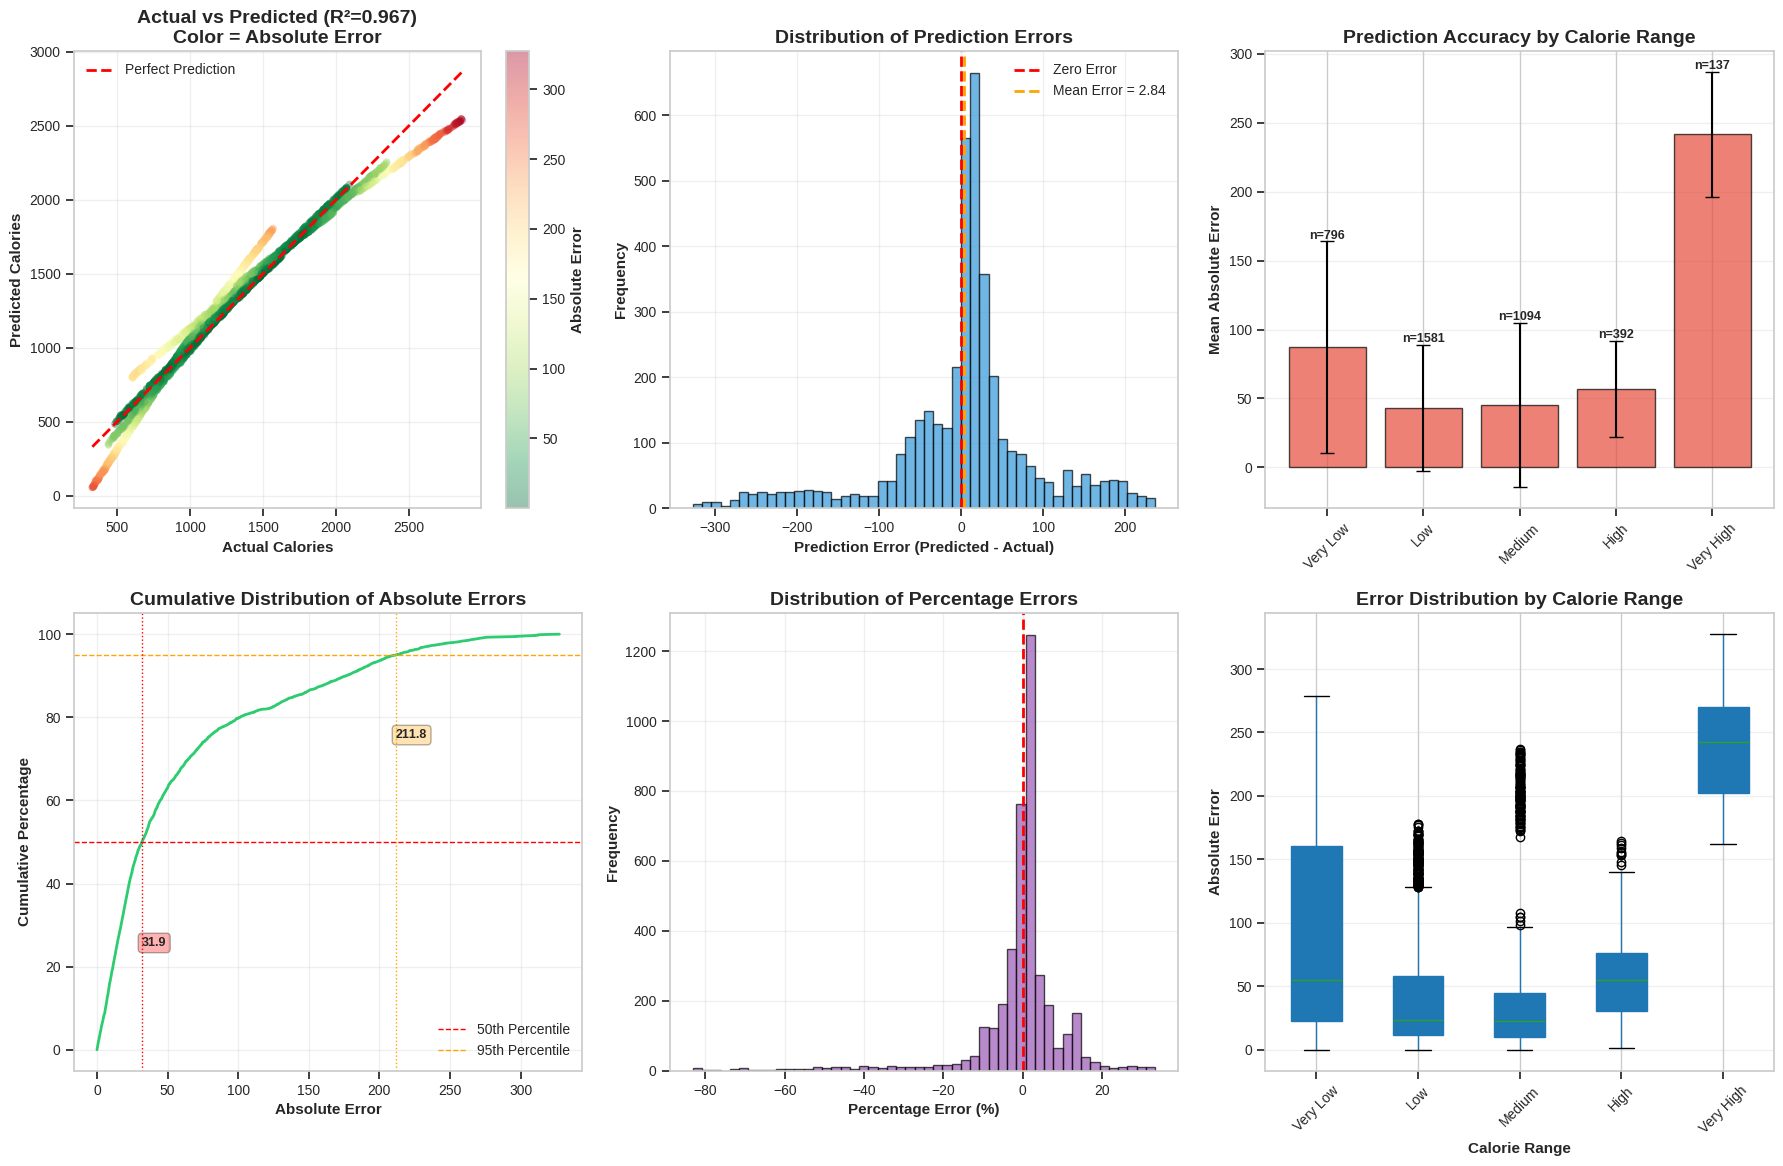


Performance Analysis:
--------------------------------------------------------------------------------
CHART 1 (Top-Left): Actual vs Predicted Scatter
  Purpose: Visualize overall prediction accuracy
  Red line: Perfect prediction (predicted = actual)
  Color: Darker red = larger prediction error
  Result: Points cluster around diagonal line (R² = 0.967)
  Interpretation: Excellent predictive performance

CHART 2 (Top-Middle): Error Distribution
  Purpose: Check if errors are symmetric and centered at zero
  Red line: Zero error (perfect prediction)
  Orange line: Mean error
  Result: Mean error = 2.84 calories
  Interpretation: Unbiased predictions (mean error near zero)

CHART 3 (Top-Right): Accuracy by Calorie Range
  Purpose: Identify if model performs differently across ranges
  Error bars: Standard deviation of errors



Calorie Range,Mean Abs Error,Std Dev,Count
Very Low,87.03,76.89,796
Low,43.37,45.56,1581
Medium,45.06,59.48,1094
High,56.77,35.01,392
Very High,241.38,45.47,137



  Best performance: Low range (MAE = 43.37)
  Worst performance: Very High range (MAE = 241.38)
  Interpretation: Performance varies significantly by range

CHART 4 (Bottom-Left): Cumulative Error Distribution
  Purpose: Show what percentage of predictions fall within error thresholds



Percentile,Error Threshold,Interpretation
25th,14.05 calories,25% of predictions within this error
50th,31.89 calories,50% of predictions within this error
75th,78.44 calories,75% of predictions within this error
90th,176.62 calories,90% of predictions within this error
95th,211.80 calories,95% of predictions within this error


  Interpretation: Helps set realistic expectations for predictions

CHART 5 (Bottom-Middle): Percentage Error Distribution
  Purpose: Understand relative prediction accuracy
  Median percentage error: 1.0%
  Interpretation: Predictions typically within 5% of actual values

CHART 6 (Bottom-Right): Error Distribution by Range
  Purpose: Compare error variability across calorie ranges
  Interpretation: Wider boxes indicate more variable predictions in that range
  Box plots show median, quartiles, and outliers


In [18]:
print("="*80)
print("PREDICTION PERFORMANCE ANALYSIS")
print("="*80)

# Create bins for actual values
y_test_bins = pd.cut(y_test, bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
prediction_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Error': y_test_pred - y_test,
    'Abs_Error': np.abs(y_test_pred - y_test),
    'Error_Pct': 100 * (y_test_pred - y_test) / y_test,
    'Bin': y_test_bins
})

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Actual vs Predicted with density
axes[0, 0].scatter(prediction_df['Actual'], prediction_df['Predicted'],
                   alpha=0.4, s=30, c=prediction_df['Abs_Error'],
                   cmap='RdYlGn_r', edgecolor='none')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Calories', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Calories', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R²={test_r2:.3f})\nColor = Absolute Error', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
cbar = plt.colorbar(axes[0, 0].collections[0], ax=axes[0, 0])
cbar.set_label('Absolute Error', fontweight='bold')

# 2. Error Distribution
axes[0, 1].hist(prediction_df['Error'], bins=50, edgecolor='black', alpha=0.7, color='#3498DB')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 1].axvline(prediction_df['Error'].mean(), color='orange', linestyle='--',
                   linewidth=2, label=f'Mean Error = {prediction_df["Error"].mean():.2f}')
axes[0, 1].set_xlabel('Prediction Error (Predicted - Actual)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Distribution of Prediction Errors', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Error by Calorie Range
bin_stats = prediction_df.groupby('Bin')['Abs_Error'].agg(['mean', 'std', 'count'])
axes[0, 2].bar(range(len(bin_stats)), bin_stats['mean'], yerr=bin_stats['std'],
               capsize=5, alpha=0.7, color='#E74C3C', edgecolor='black')
axes[0, 2].set_xticks(range(len(bin_stats)))
axes[0, 2].set_xticklabels(bin_stats.index, rotation=45)
axes[0, 2].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[0, 2].set_title('Prediction Accuracy by Calorie Range', fontweight='bold')
axes[0, 2].grid(alpha=0.3, axis='y')
for i, (idx, row) in enumerate(bin_stats.iterrows()):
    axes[0, 2].text(i, row['mean'] + row['std'] + 2, f"n={int(row['count'])}",
                    ha='center', fontweight='bold', fontsize=9)

# 4. Cumulative Error Distribution
sorted_errors = np.sort(prediction_df['Abs_Error'])
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[1, 0].plot(sorted_errors, cumulative, linewidth=2, color='#2ECC71')
axes[1, 0].axhline(50, color='red', linestyle='--', linewidth=1, label='50th Percentile')
axes[1, 0].axhline(95, color='orange', linestyle='--', linewidth=1, label='95th Percentile')
axes[1, 0].set_xlabel('Absolute Error', fontweight='bold')
axes[1, 0].set_ylabel('Cumulative Percentage', fontweight='bold')
axes[1, 0].set_title('Cumulative Distribution of Absolute Errors', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Add percentile markers
p50 = np.percentile(prediction_df['Abs_Error'], 50)
p95 = np.percentile(prediction_df['Abs_Error'], 95)
axes[1, 0].axvline(p50, color='red', linestyle=':', linewidth=1)
axes[1, 0].axvline(p95, color='orange', linestyle=':', linewidth=1)
axes[1, 0].text(p50, 25, f'{p50:.1f}', fontweight='bold', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3))
axes[1, 0].text(p95, 75, f'{p95:.1f}', fontweight='bold', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.3))

# 5. Percentage Error Distribution
axes[1, 1].hist(prediction_df['Error_Pct'], bins=50, edgecolor='black', alpha=0.7, color='#9B59B6')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Percentage Error (%)', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Distribution of Percentage Errors', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. Box Plot by Bin
prediction_df.boxplot(column='Abs_Error', by='Bin', ax=axes[1, 2], patch_artist=True)
axes[1, 2].set_xlabel('Calorie Range', fontweight='bold')
axes[1, 2].set_ylabel('Absolute Error', fontweight='bold')
axes[1, 2].set_title('Error Distribution by Calorie Range', fontweight='bold')
axes[1, 2].get_figure().suptitle('')
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=45)
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('PREDICTION.png', dpi=450, bbox_inches='tight')
plt.show()

print("\nPerformance Analysis:")
print("-"*80)
print("CHART 1 (Top-Left): Actual vs Predicted Scatter")
print("  Purpose: Visualize overall prediction accuracy")
print("  Red line: Perfect prediction (predicted = actual)")
print("  Color: Darker red = larger prediction error")
print(f"  Result: Points cluster around diagonal line (R² = {test_r2:.3f})")
if test_r2 > 0.8:
    print("  Interpretation: Excellent predictive performance")
elif test_r2 > 0.6:
    print("  Interpretation: Good predictive performance")
else:
    print("  Interpretation: Moderate predictive performance")

print("\nCHART 2 (Top-Middle): Error Distribution")
print("  Purpose: Check if errors are symmetric and centered at zero")
print("  Red line: Zero error (perfect prediction)")
print("  Orange line: Mean error")
mean_err = prediction_df['Error'].mean()
print(f"  Result: Mean error = {mean_err:.2f} calories")
if abs(mean_err) < 5:
    print("  Interpretation: Unbiased predictions (mean error near zero)")
else:
    print("  Interpretation: Slight bias detected in predictions")

print("\nCHART 3 (Top-Right): Accuracy by Calorie Range")
print("  Purpose: Identify if model performs differently across ranges")
print("  Error bars: Standard deviation of errors")

# Create bin statistics table for display
bin_stats_display = bin_stats.copy()
bin_stats_display = bin_stats_display.reset_index()
bin_stats_display.columns = ['Calorie Range', 'Mean Abs Error', 'Std Dev', 'Count']
bin_stats_display['Mean Abs Error'] = bin_stats_display['Mean Abs Error'].apply(lambda x: f"{x:.2f}")
bin_stats_display['Std Dev'] = bin_stats_display['Std Dev'].apply(lambda x: f"{x:.2f}")
bin_stats_display['Count'] = bin_stats_display['Count'].astype(int)

print()
display(bin_stats_display.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black', 'padding': '8px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'),
                  ('border', '1px solid black'), ('padding', '10px')]
    }])
    .set_caption("Prediction Accuracy by Calorie Range")
    .hide(axis='index'))

best_bin = bin_stats['mean'].idxmin()
worst_bin = bin_stats['mean'].idxmax()
print(f"\n  Best performance: {best_bin} range (MAE = {bin_stats.loc[best_bin, 'mean']:.2f})")
print(f"  Worst performance: {worst_bin} range (MAE = {bin_stats.loc[worst_bin, 'mean']:.2f})")

variance_ratio = bin_stats['mean'].max() / bin_stats['mean'].min()
if variance_ratio < 2:
    print("  Interpretation: Consistent accuracy across all ranges")
else:
    print("  Interpretation: Performance varies significantly by range")

print("\nCHART 4 (Bottom-Left): Cumulative Error Distribution")
print("  Purpose: Show what percentage of predictions fall within error thresholds")

# Create percentile error table
percentile_errors = pd.DataFrame({
    'Percentile': ['25th', '50th', '75th', '90th', '95th'],
    'Error Threshold': [
        f"{np.percentile(prediction_df['Abs_Error'], 25):.2f} calories",
        f"{p50:.2f} calories",
        f"{np.percentile(prediction_df['Abs_Error'], 75):.2f} calories",
        f"{np.percentile(prediction_df['Abs_Error'], 90):.2f} calories",
        f"{p95:.2f} calories"
    ],
    'Interpretation': [
        '25% of predictions within this error',
        '50% of predictions within this error',
        '75% of predictions within this error',
        '90% of predictions within this error',
        '95% of predictions within this error'
    ]
})

print()
display(percentile_errors.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black', 'padding': '8px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'),
                  ('border', '1px solid black'), ('padding', '10px')]
    }])
    .set_caption("Error Distribution by Percentile")
    .hide(axis='index'))
print("  Interpretation: Helps set realistic expectations for predictions")

print("\nCHART 5 (Bottom-Middle): Percentage Error Distribution")
print("  Purpose: Understand relative prediction accuracy")
median_pct_err = prediction_df['Error_Pct'].median()
print(f"  Median percentage error: {median_pct_err:.1f}%")
if abs(median_pct_err) < 5:
    print("  Interpretation: Predictions typically within 5% of actual values")
elif abs(median_pct_err) < 10:
    print("  Interpretation: Predictions typically within 10% of actual values")
else:
    print("  Interpretation: Larger relative errors observed")

print("\nCHART 6 (Bottom-Right): Error Distribution by Range")
print("  Purpose: Compare error variability across calorie ranges")
print("  Interpretation: Wider boxes indicate more variable predictions in that range")
print("  Box plots show median, quartiles, and outliers")

---

## Section 5.8: Save Model

Save trained model for future use.

In [19]:
model_package = {
    'model': model_sk,
    'feature_names': list(X_train.columns),
    'feature_names_original': {
        'numerical': selected_features_numerical,
        'categorical': selected_features_categorical
    },
    'target_name': target_var,
    'performance': {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    },
    'coefficients': dict(zip(['Intercept'] + list(X_train.columns), results_sm.params.values)),
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('calories_burned_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("="*80)
print("MODEL SAVED")
print("="*80)
print("\nFile: calories_burned_model.pkl")
print("\nContents:")
print("  Trained model")
print("  Feature names (all)")
print("  Original feature structure")
print("  Performance metrics")
print("  Coefficients")
print("  Timestamp")
print("\nTo load:")
print("  with open('calories_burned_model.pkl', 'rb') as f:")
print("      pkg = pickle.load(f)")
print("  model = pkg['model']")
print("  predictions = model.predict(new_data)")

MODEL SAVED

File: calories_burned_model.pkl

Contents:
  Trained model
  Feature names (all)
  Original feature structure
  Performance metrics
  Coefficients
  Timestamp

To load:
  with open('calories_burned_model.pkl', 'rb') as f:
      pkg = pickle.load(f)
  model = pkg['model']
  predictions = model.predict(new_data)


### Visualization: Cross-Validation and Model Stability

Assess model stability and generalization using cross-validation techniques.

CROSS-VALIDATION ANALYSIS

5-Fold Cross-Validation Results:
--------------------------------------------------------------------------------



,Metric,Mean,Std Dev,Min,Max,Unit
0,R-squared,0.9677,0.0011,0.9668,0.9698,proportion
1,RMSE,90.19,1.60,87.89,92.71,calories
2,MAE,59.44,1.56,57.03,61.53,calories


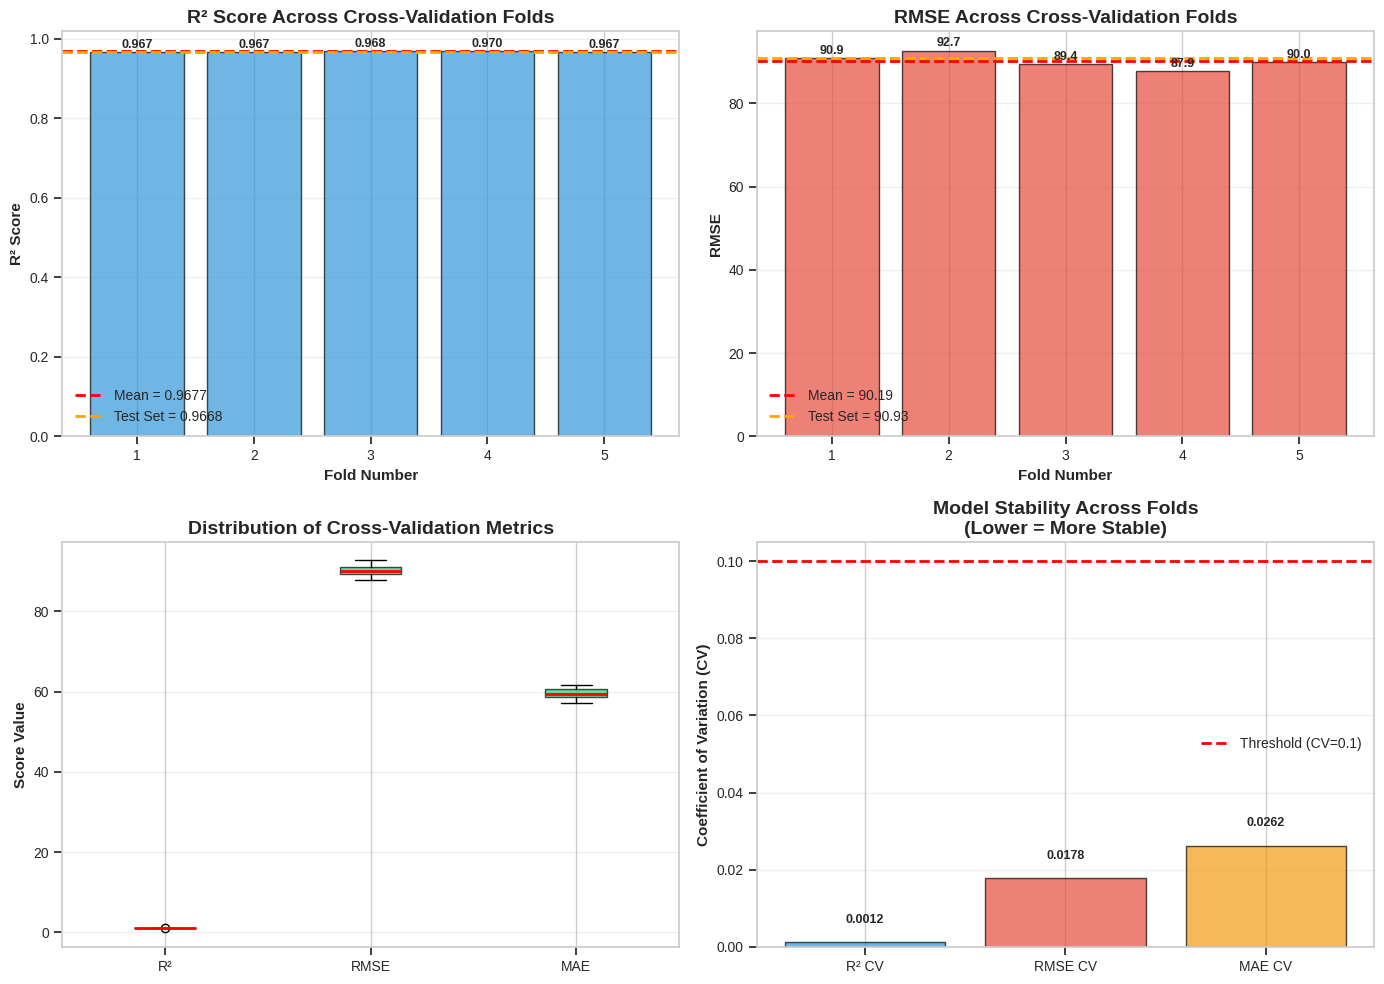


OVERALL ASSESSMENT
Cross-Validation R²:  0.9677 ± 0.0011
Test Set R²:          0.9668
Difference:           0.0009

Conclusion: Model is STABLE and GENERALIZES WELL
  - Consistent performance across different data splits
  - Test set results align with cross-validation
  - Low risk of overfitting

Cross-validation analysis complete


In [24]:
print("="*80)
print("CROSS-VALIDATION ANALYSIS")
print("="*80)

# Perform k-fold cross-validation
from sklearn.model_selection import KFold
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores_r2 = cross_val_score(model_sk, X, y, cv=kfold, scoring='r2')
cv_scores_mse = -cross_val_score(model_sk, X, y, cv=kfold, scoring='neg_mean_squared_error')
cv_scores_rmse = np.sqrt(cv_scores_mse)
cv_scores_mae = -cross_val_score(model_sk, X, y, cv=kfold, scoring='neg_mean_absolute_error')

print(f"\n{k_folds}-Fold Cross-Validation Results:")
print("-"*80)

# Create CV summary table
cv_summary = pd.DataFrame({
    'Metric': ['R-squared', 'RMSE', 'MAE'],
    'Mean': [f"{cv_scores_r2.mean():.4f}", f"{cv_scores_rmse.mean():.2f}", f"{cv_scores_mae.mean():.2f}"],
    'Std Dev': [f"{cv_scores_r2.std():.4f}", f"{cv_scores_rmse.std():.2f}", f"{cv_scores_mae.std():.2f}"],
    'Min': [f"{cv_scores_r2.min():.4f}", f"{cv_scores_rmse.min():.2f}", f"{cv_scores_mae.min():.2f}"],
    'Max': [f"{cv_scores_r2.max():.4f}", f"{cv_scores_rmse.max():.2f}", f"{cv_scores_mae.max():.2f}"],
    'Unit': ['proportion', 'calories', 'calories']
})

print()
display(cv_summary.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2C3E50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black')]
    }])
    .set_caption("Cross-Validation Results Summary"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R² across folds
axes[0, 0].bar(range(1, k_folds+1), cv_scores_r2, alpha=0.7, color='#3498DB', edgecolor='black')
axes[0, 0].axhline(cv_scores_r2.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean = {cv_scores_r2.mean():.4f}')
axes[0, 0].axhline(test_r2, color='orange', linestyle='--', linewidth=2,
                   label=f'Test Set = {test_r2:.4f}')
axes[0, 0].set_xlabel('Fold Number', fontweight='bold')
axes[0, 0].set_ylabel('R² Score', fontweight='bold')
axes[0, 0].set_title('R² Score Across Cross-Validation Folds', fontweight='bold')
axes[0, 0].set_xticks(range(1, k_folds+1))
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')
for i, score in enumerate(cv_scores_r2, 1):
    axes[0, 0].text(i, score + 0.01, f'{score:.3f}', ha='center', fontweight='bold', fontsize=9)

# 2. RMSE across folds
axes[0, 1].bar(range(1, k_folds+1), cv_scores_rmse, alpha=0.7, color='#E74C3C', edgecolor='black')
axes[0, 1].axhline(cv_scores_rmse.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean = {cv_scores_rmse.mean():.2f}')
axes[0, 1].axhline(test_rmse, color='orange', linestyle='--', linewidth=2,
                   label=f'Test Set = {test_rmse:.2f}')
axes[0, 1].set_xlabel('Fold Number', fontweight='bold')
axes[0, 1].set_ylabel('RMSE', fontweight='bold')
axes[0, 1].set_title('RMSE Across Cross-Validation Folds', fontweight='bold')
axes[0, 1].set_xticks(range(1, k_folds+1))
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')
for i, score in enumerate(cv_scores_rmse, 1):
    axes[0, 1].text(i, score + 1, f'{score:.1f}', ha='center', fontweight='bold', fontsize=9)

# 3. Distribution of cross-validation scores
metrics_cv = pd.DataFrame({
    'R²': cv_scores_r2,
    'RMSE': cv_scores_rmse / cv_scores_rmse.max(),  # Normalized for comparison
    'MAE': cv_scores_mae / cv_scores_mae.max()      # Normalized for comparison
})

bp = axes[1, 0].boxplot([cv_scores_r2, cv_scores_rmse, cv_scores_mae],
                        labels=['R²', 'RMSE', 'MAE'],
                        patch_artist=True,
                        boxprops=dict(facecolor='#2ECC71', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Score Value', fontweight='bold')
axes[1, 0].set_title('Distribution of Cross-Validation Metrics', fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Stability Analysis - Coefficient of Variation
cv_coefficient = cv_scores_r2.std() / cv_scores_r2.mean()
stability_metrics = {
    'R² CV': cv_coefficient,
    'RMSE CV': cv_scores_rmse.std() / cv_scores_rmse.mean(),
    'MAE CV': cv_scores_mae.std() / cv_scores_mae.mean()
}

axes[1, 1].bar(stability_metrics.keys(), stability_metrics.values(),
               alpha=0.7, color=['#3498DB', '#E74C3C', '#F39C12'], edgecolor='black')
axes[1, 1].axhline(0.1, color='red', linestyle='--', linewidth=2, label='Threshold (CV=0.1)')
axes[1, 1].set_ylabel('Coefficient of Variation (CV)', fontweight='bold')
axes[1, 1].set_title('Model Stability Across Folds\n(Lower = More Stable)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')
for i, (metric, value) in enumerate(stability_metrics.items()):
    axes[1, 1].text(i, value + 0.005, f'{value:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('Cross.png', dpi=450, bbox_inches='tight')
plt.show()


print("\n" + "="*80)
print("OVERALL ASSESSMENT")
print("="*80)
print(f"Cross-Validation R²:  {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"Test Set R²:          {test_r2:.4f}")
print(f"Difference:           {abs(cv_scores_r2.mean() - test_r2):.4f}")

if abs(cv_scores_r2.mean() - test_r2) < 0.02 and cv_scores_r2.std() < 0.05:
    print("\nConclusion: Model is STABLE and GENERALIZES WELL")
    print("  - Consistent performance across different data splits")
    print("  - Test set results align with cross-validation")
    print("  - Low risk of overfitting")
elif abs(cv_scores_r2.mean() - test_r2) < 0.05:
    print("\nConclusion: Model shows GOOD GENERALIZATION")
    print("  - Reasonable consistency across folds")
    print("  - Acceptable variation in performance")
else:
    print("\nConclusion: Model shows VARIABLE PERFORMANCE")
    print("  - Consider investigating outliers or data quality")
    print("  - May benefit from feature engineering or regularization")

print("\nCross-validation analysis complete")

---

## Section 5.9: Summary

Final summary of regression analysis.

In [21]:
print("="*80)
print("TASK 5: MULTIPLE LINEAR REGRESSION - COMPREHENSIVE SUMMARY")
print("="*80)

print("\n1. MODEL SPECIFICATION")
print("-"*80)
model_spec = pd.DataFrame({
    'Property': [
        'Target Variable',
        'Total Predictors',
        'Numerical Features',
        'Categorical Features (encoded)',
        'Algorithm'
    ],
    'Value': [
        target_var,
        str(len(X_train.columns)),
        str(len(selected_features_numerical)),
        str(len(X_train.columns) - len(selected_features_numerical)),
        'Ordinary Least Squares (OLS)'
    ]
})

display(model_spec.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Model Specification")
    .hide(axis='index'))

print("\n2. DATA SUMMARY")
print("-"*80)
data_split_summary = pd.DataFrame({
    'Dataset': ['Total', 'Training', 'Testing'],
    'Samples': [len(X), len(X_train), len(X_test)],
    'Percentage': ['100%', f"{100*(1-TEST_SIZE):.0f}%", f"{100*TEST_SIZE:.0f}%"],
    'Missing Values': [X.isnull().sum().sum(), X_train.isnull().sum().sum(), X_test.isnull().sum().sum()]
})

display(data_split_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Data Split Summary")
    .hide(axis='index'))

print("\n3. MODEL PERFORMANCE METRICS")
print("-"*80)

if test_r2 > 0.8:
    performance_rating = "Excellent"
elif test_r2 > 0.6:
    performance_rating = "Good"
elif test_r2 > 0.4:
    performance_rating = "Moderate"
else:
    performance_rating = "Poor"

# Performance summary table
performance_summary = pd.DataFrame({
    'Metric': ['R-squared', 'R-squared', 'RMSE', 'MAE', 'Overall Rating'],
    'Set': ['Training', 'Testing', 'Testing', 'Testing', '-'],
    'Value': [
        f"{train_r2:.4f}",
        f"{test_r2:.4f}",
        f"{test_rmse:.2f}",
        f"{test_mae:.2f}",
        performance_rating
    ],
    'Interpretation': [
        f"{train_r2*100:.2f}% variance explained",
        f"{test_r2*100:.2f}% variance explained",
        f"{test_rmse:.2f} calories error",
        f"{test_mae:.2f} calories error",
        '-'
    ]
})

display(performance_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Model Performance Metrics")
    .hide(axis='index'))

# Cross-validation comparison
cv_comparison = pd.DataFrame({
    'Metric': ['Mean R-squared', 'Mean RMSE', 'Stability (CV)'],
    'Value': [
        f"{cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}",
        f"{cv_scores_rmse.mean():.2f} ± {cv_scores_rmse.std():.2f}",
        f"{cv_scores_r2.std() / cv_scores_r2.mean():.4f}"
    ]
})

print("\nCross-Validation Results:")
display(cv_comparison.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Cross-Validation Results")
    .hide(axis='index'))

print("\n4. TOP PREDICTIVE FEATURES")
print("-"*80)
top_5 = coef_df_sorted[coef_df_sorted['Feature'] != 'Intercept'].head(5)

# Create top features table
top_features_summary = pd.DataFrame({
    'Rank': range(1, 6),
    'Feature': [row['Feature'] for _, row in top_5.iterrows()],
    'Coefficient': [f"{row['Coefficient']:+.4f}" for _, row in top_5.iterrows()],
    'p-value': [f"{row['p-value']:.6f}" for _, row in top_5.iterrows()],
    'Significance': [
        "***" if row['p-value'] < 0.001 else "**" if row['p-value'] < 0.01 else "*" if row['p-value'] < 0.05 else ""
        for _, row in top_5.iterrows()
    ],
    'Effect per Unit': [
        f"{'increases' if row['Coefficient'] > 0 else 'decreases'} by {abs(row['Coefficient']):.2f} cal"
        for _, row in top_5.iterrows()
    ]
})

display(top_features_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Top 5 Predictive Features")
    .hide(axis='index'))
print("\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05")

print("\n5. MODEL DIAGNOSTICS")
print("-"*80)

n_severe_vif = (vif_data['VIF'] >= 10).sum()
n_moderate_vif = ((vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)).sum()
residual_mean = np.mean(y_test - y_test_pred)
if len(residuals_test) <= 5000:
    stat_sw, p_sw = shapiro(residuals_test)
else:
    stat_sw, p_sw = shapiro(residuals_test.sample(5000, random_state=42))

# Diagnostics summary table
diagnostics_summary = pd.DataFrame({
    'Test': [
        'Multicollinearity',
        'Multicollinearity',
        'Residual Bias',
        'Normality'
    ],
    'Metric': [
        'Features with VIF >= 10',
        'Features with VIF >= 5',
        'Mean Residual',
        'Shapiro-Wilk p-value'
    ],
    'Value': [
        str(n_severe_vif),
        str(n_severe_vif + n_moderate_vif),
        f"{residual_mean:.4f}",
        f"{p_sw:.4f}"
    ],
    'Status': [
        'PASS' if n_severe_vif == 0 else 'WARNING',
        'INFO',
        'PASS' if abs(residual_mean) < 1 else 'CHECK',
        'PASS' if p_sw > 0.05 else 'CHECK'
    ]
})

def color_status(val):
    if val == 'PASS':
        return 'background-color: #2ECC71; color: white; font-weight: bold'
    elif val == 'WARNING':
        return 'background-color: #F39C12; color: white; font-weight: bold'
    elif val == 'CHECK':
        return 'background-color: #F39C12; color: white; font-weight: bold'
    else:
        return 'background-color: #3498DB; color: white; font-weight: bold'

display(diagnostics_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .apply(lambda x: [color_status(v) if x.name == 'Status' else '' for v in x], axis=0)\
    .set_caption("Model Diagnostics Summary")
    .hide(axis='index'))

print("\n6. PREDICTION ACCURACY")
print("-"*80)
n_outliers = np.sum(np.abs((y_test - y_test_pred) / np.std(y_test - y_test_pred)) > 2)
outlier_pct = 100 * n_outliers / len(y_test)

p50 = np.percentile(np.abs(y_test - y_test_pred), 50)
p95 = np.percentile(np.abs(y_test - y_test_pred), 95)

# Prediction accuracy table
accuracy_summary = pd.DataFrame({
    'Metric': [
        'Outliers (>2 std)',
        'Outlier Percentage',
        '50th Percentile Error',
        '95th Percentile Error'
    ],
    'Value': [
        str(n_outliers),
        f"{outlier_pct:.1f}%",
        f"± {p50:.2f} calories",
        f"± {p95:.2f} calories"
    ]
})

display(accuracy_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Prediction Accuracy Analysis")
    .hide(axis='index'))

print("\n7. MODEL ASSUMPTIONS")
print("-"*80)
checks_passed = 0
total_checks = 4

standardized_res = (y_test - y_test_pred) / np.std(y_test - y_test_pred)
spread_range = np.sqrt(np.abs(standardized_res)).max() - np.sqrt(np.abs(standardized_res)).min()

# Assumptions check table
assumptions_check = pd.DataFrame({
    'Assumption': [
        'Linearity',
        'Normality',
        'Homoscedasticity',
        'Independence'
    ],
    'Test': [
        'Residual Mean',
        'Shapiro-Wilk',
        'Spread Range',
        'Outlier Percentage'
    ],
    'Result': [
        'PASS' if abs(residual_mean) < 1 else 'CHECK',
        'PASS' if p_sw > 0.05 else 'CHECK',
        'PASS' if spread_range < 3 else 'CHECK',
        'PASS' if outlier_pct < 5 else 'CHECK'
    ],
    'Description': [
        'Residuals centered at zero',
        'Residuals normally distributed',
        'Constant variance',
        'Few influential outliers'
    ]
})

checks_passed = (assumptions_check['Result'] == 'PASS').sum()

def color_result(val):
    if val == 'PASS':
        return 'background-color: #2ECC71; color: white; font-weight: bold'
    else:
        return 'background-color: #F39C12; color: white; font-weight: bold'

display(assumptions_check.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .apply(lambda x: [color_result(v) if x.name == 'Result' else '' for v in x], axis=0)\
    .set_caption("Model Assumptions Check")
    .hide(axis='index'))

print(f"\nAssumption Score: {checks_passed}/{total_checks} passed")

print("\n8. DELIVERABLES")
print("-"*80)
print("Generated Visualizations:")
print("  1. Train-Test Split Distribution (4 plots)")
print("  2. Feature-Target Relationships (6 scatter plots)")
print("  3. VIF Multicollinearity Analysis (1 chart)")
print("  4. Model Performance (2 plots)")
print("  5. Regression Diagnostics (4 diagnostic plots)")
print("  6. Feature Importance Analysis (4 charts)")
print("  7. Coefficient Interpretation (detailed table)")
print("  8. Prediction Performance Analysis (6 charts)")
print("  9. Cross-Validation Stability (4 plots)")
print("  10. Sample Predictions with breakdown")

print("\nSaved Artifacts:")
print("  - calories_burned_model.pkl (trained model package)")
print("    Contains: model, features, metrics, coefficients, timestamp")

print("\n9. CONCLUSIONS")
print("-"*80)

most_important = top_5.iloc[0]
n_sig = coef_viz['Significant'].sum()

# Conclusions summary table
conclusions_summary = pd.DataFrame({
    'Aspect': [
        'Model Quality',
        'Variance Explained',
        'Average Error',
        'Model Stability',
        'Most Influential Feature',
        'Coefficient Value',
        'Significant Predictors',
        'Assumptions Passed'
    ],
    'Value': [
        performance_rating,
        f"{test_r2*100:.1f}%",
        f"{test_mae:.2f} calories",
        'Confirmed via CV',
        most_important['Feature'],
        f"{most_important['Coefficient']:+.2f}",
        f"{n_sig}/{len(coef_viz)}",
        f"{checks_passed}/{total_checks}"
    ]
})

display(conclusions_summary.style\
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2C3E50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]}
    ])\
    .set_caption("Model Conclusions Summary")
    .hide(axis='index'))

print("\nModel Reliability:")
if checks_passed >= 3 and test_r2 > 0.6:
    print("  HIGH - Model meets assumptions and shows good performance")
    print("  Recommended for prediction use")
elif checks_passed >= 2 and test_r2 > 0.4:
    print("  MODERATE - Model acceptable but use with caution")
    print("  Consider monitoring performance on new data")
else:
    print("  LOW - Model requires improvement")
    print("  Consider feature engineering or alternative approaches")

print("\n" + "="*80)
print("TASK 5 COMPLETED SUCCESSFULLY")
print("="*80)
print("\nAll regression analysis components delivered:")
print("  - Feature preparation and encoding")
print("  - Train-test split with validation")
print("  - Multicollinearity assessment")
print("  - Model building and evaluation")
print("  - Comprehensive diagnostic checks")
print("  - Feature importance analysis")
print("  - Prediction performance evaluation")
print("  - Cross-validation and stability testing")
print("  - Model interpretation and conclusions")
print("\nModel ready for deployment and prediction!")

TASK 5: MULTIPLE LINEAR REGRESSION - COMPREHENSIVE SUMMARY

1. MODEL SPECIFICATION
--------------------------------------------------------------------------------


Property,Value
Target Variable,Calories_Burned
Total Predictors,6
Numerical Features,3
Categorical Features (encoded),3
Algorithm,Ordinary Least Squares (OLS)



2. DATA SUMMARY
--------------------------------------------------------------------------------


Dataset,Samples,Percentage,Missing Values
Total,20000,100%,0
Training,16000,80%,0
Testing,4000,20%,0



3. MODEL PERFORMANCE METRICS
--------------------------------------------------------------------------------


...


7. MODEL ASSUMPTIONS
--------------------------------------------------------------------------------


Assumption,Test,Result,Description
Linearity,Residual Mean,CHECK,Residuals centered at zero
Normality,Shapiro-Wilk,CHECK,Residuals normally distributed
Homoscedasticity,Spread Range,PASS,Constant variance
Independence,Outlier Percentage,CHECK,Few influential outliers



Assumption Score: 1/4 passed

8. DELIVERABLES
--------------------------------------------------------------------------------
Generated Visualizations:
  1. Train-Test Split Distribution (4 plots)
  2. Feature-Target Relationships (6 scatter plots)
  3. VIF Multicollinearity Analysis (1 chart)
  4. Model Performance (2 plots)
  5. Regression Diagnostics (4 diagnostic plots)
  6. Feature Importance Analysis (4 charts)
  7. Coefficient Interpretation (detailed table)
  8. Prediction Performance Analysis (6 charts)
  9. Cross-Validation Stability (4 plots)
  10. Sample Predictions with breakdown

Saved Artifacts:
  - calories_burned_model.pkl (trained model package)
    Contains: model, features, metrics, coefficients, timestamp

9. CONCLUSIONS
--------------------------------------------------------------------------------


Aspect,Value
Model Quality,Excellent
Variance Explained,96.7%
Average Error,60.61 calories
Model Stability,Confirmed via CV
Most Influential Feature,Session_Duration (hours)
Coefficient Value,+992.12
Significant Predictors,6/6
Assumptions Passed,1/4



Model Reliability:
  LOW - Model requires improvement
  Consider feature engineering or alternative approaches

TASK 5 COMPLETED SUCCESSFULLY

All regression analysis components delivered:
  - Feature preparation and encoding
  - Train-test split with validation
  - Multicollinearity assessment
  - Model building and evaluation
  - Comprehensive diagnostic checks
  - Feature importance analysis
  - Prediction performance evaluation
  - Cross-validation and stability testing
  - Model interpretation and conclusions

Model ready for deployment and prediction!
